In [1]:
import pandas as pd
import numpy as p
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
le = LabelEncoder()
df['Gender_Id'] = le.fit_transform(df['Gender'])

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_Id'],
      dtype='object')

### Features

In [21]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']

In [22]:
X = df[features]

In [23]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

### Elbow Method

In [24]:
error_rate = []
k_range = range(1, 21)

In [25]:
for i in k_range:
    kmean = KMeans(n_clusters = i)
    kmean.fit_predict(X_scale)
    error_rate.append(kmean.inertia_)

Text(0.5, 1.0, 'Elbow Method - Choosing Optimal Number of Clusters')

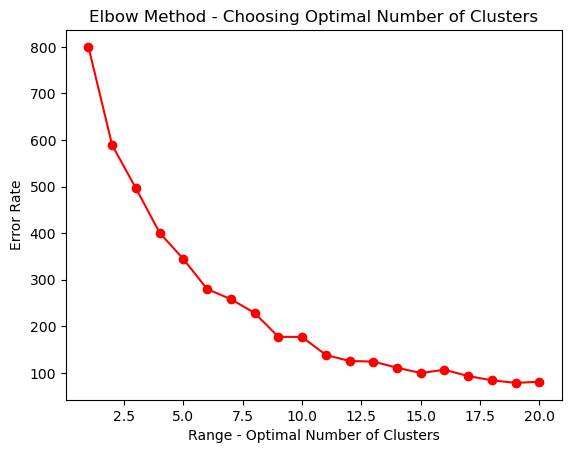

In [26]:
plt.plot(k_range, error_rate, color='red', marker='o')
plt.xlabel('Range - Optimal Number of Clusters')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Choosing Optimal Number of Clusters')

In [27]:
k = 5
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)
# df['clusters'] = clusters

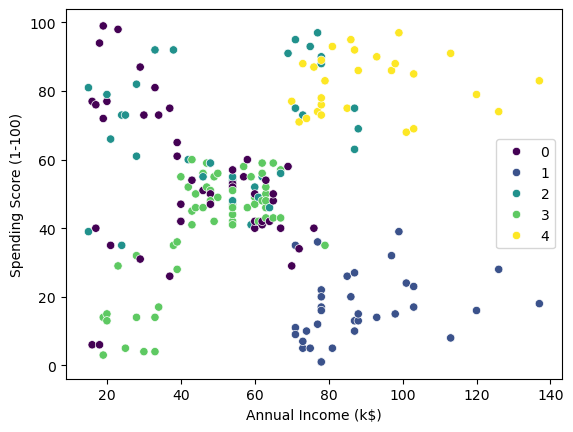

In [28]:
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=clusters, palette='viridis')
plt.show()

In [29]:
cluster = model.labels_
df['cluster'] = cluster

In [30]:
pair_plot = df

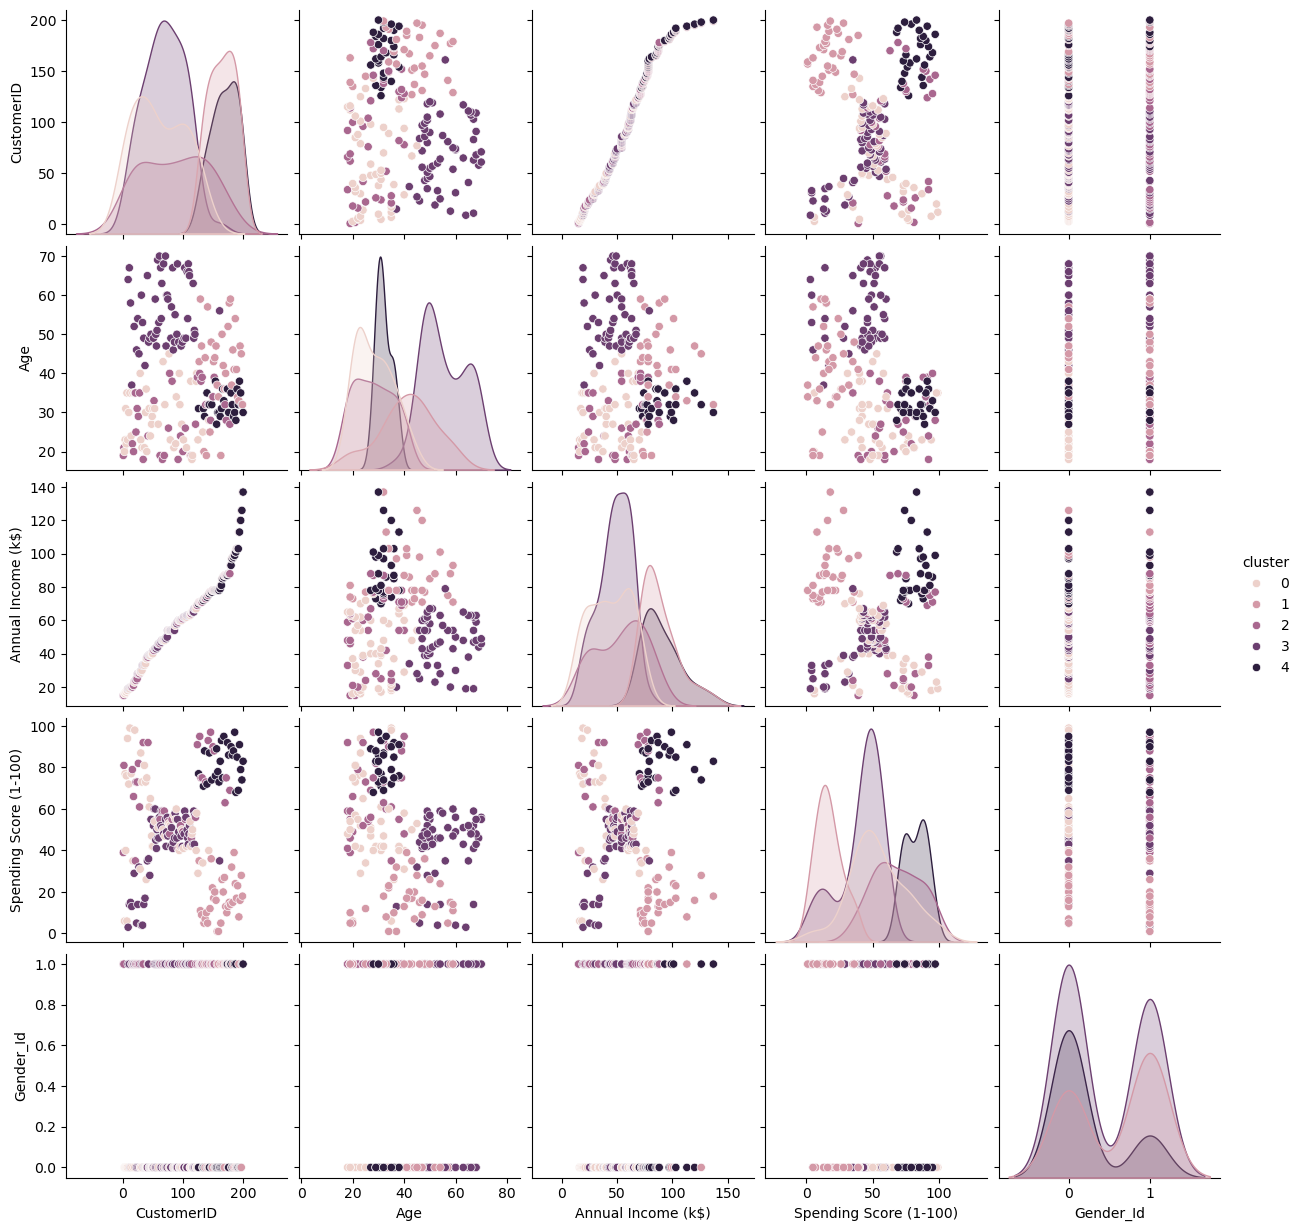

In [31]:
sns.pairplot(
    pair_plot,
    hue='cluster'
)
plt.savefig('pp.png')

In [32]:
total_customer = df.groupby('cluster')['CustomerID'].count().reset_index()
total_customer

,cluster,CustomerID
0,0,46
1,1,34
2,2,36
3,3,57
4,4,27


In [33]:
from sklearn.decomposition import PCA

In [35]:
pca = PCA(n_components=len(features))

In [38]:
# covariance
X_model = pca.fit_transform(X_scale)

In [42]:
loadings = pd.DataFrame(
    pca.components_, # covariance -> eigenvalues and eigenvectors,
    index=features,
    columns = [f'PC{i+1}' for i in range(len(features))]
)
loadings

,PC1,PC2,PC3,PC4
Age,0.687900,-0.006082,-0.686920,0.234302
Annual Income (k$),-0.103690,0.765252,0.103211,0.626886
Spending Score (1-100),-0.122384,-0.643667,0.136573,0.743009
Gender_Id,0.707859,0.006721,0.706283,-0.007405


Text(0, 0.5, 'Principle Component 2')

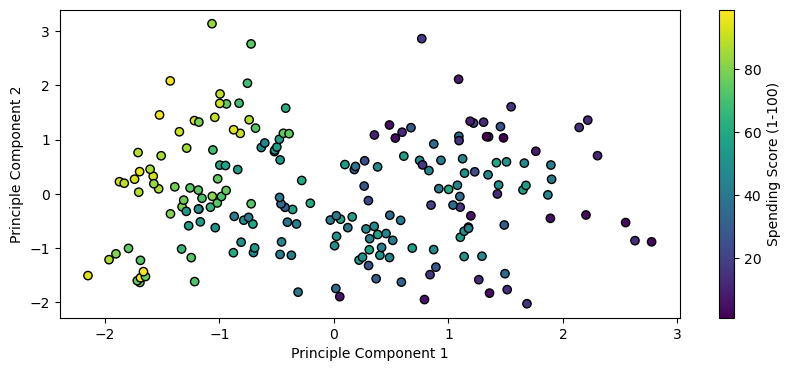

In [54]:
# X-axis -> Age, Gender id
# Y-axis -> Annual Income, Spending Score
col = 'Spending Score (1-100)'
plt.figure(figsize=(10, 4))
scatter = plt.scatter(X_model[:,0], X_model[:,1], c=df[col], edgecolor='black')
plt.colorbar(scatter, label=col)
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')